# 07 — CHIME Raw vs Convolved vs RT1 in-situ: full algorithm comparison

**Goal:** Read all CHIME data sources independently, compute every algorithm from scratch,
then compare:
- Raw CHIME (5 nm, 10 nm) vs AQUATIME convolved CSVs (same resolutions)
- Both CHIME datasets vs RT1 in-situ PANTHYR reference

**Data sources:**
| ID | File | Type | Δλ |
|---|---|---|---|
| `raw_5nm` | `chime_05_belgium` | Raw CHIME | 5 nm |
| `raw_10nm` | `chime_10_belgium` | Raw CHIME | 10 nm |
| `conv_5nm` | `AQUATIME_D2.1.0_...chime-convolved-5nm-v0.1` | Convolved CSV | 5 nm |
| `conv_10nm` | `AQUATIME_D2.1.0_...chime-convolved-10nm-v0.1` | Convolved CSV | 10 nm |
| `rt1` | `REFERENCE_DATASET_4_WP2_RT1_2025.csv` | In-situ PANTHYR | 2.5 nm |

## 0 — Configuration

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d
from scipy.stats import mannwhitneyu
from pathlib import Path
from phytospec.algorithms import compute_MALH, compute_CHL, compute_D2, lubac_phaeo_index
from phytospec import config as cfg
from phytospec import algorithms as alg
from phytospec import config as cfg
print('phytospec imported from:', Path(alg.__file__).parent)
import warnings; warnings.filterwarnings('ignore')

# ── File paths ────────────────────────────────────────────────────────────────




# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_RAW       = cfg.DATA_RAW / "CHIME" 
DATA_PROCESSED = cfg.DATA_PROCESSED 
RT1_FILE       = cfg.DATA_PROCESSED / 'REFERENCE_DATASET_4_WP2_RT1_2025.csv'
FIG_DIR        = cfg.FIGURES_DIR / 'figures_aquatime'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── File registry ─────────────────────────────────────────────────────────────
# delta_nm: ACTUAL wavelength spacing — critical for D² (denominator = delta²)
FILE_REGISTRY = [
    dict(id='raw_5nm',   path=DATA_RAW / 'chime_05_belgium',
         label='Raw 5 nm',   fmt='raw', delta_nm=5.0,  color='#1D9E75'),
    dict(id='raw_10nm',  path=DATA_RAW / 'chime_10_belgium',
         label='Raw 10 nm',  fmt='raw', delta_nm=10.0, color='#185FA5'),
    dict(id='conv_5nm',  path=DATA_RAW / 'AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1',
         label='Conv 5 nm',  fmt='csv', delta_nm=5.0,  color='#D85A30'),
    dict(id='conv_10nm', path=DATA_RAW / 'AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1',
         label='Conv 10 nm', fmt='csv', delta_nm=10.0, color='#8B5CF6'),
]



print(f'  cfg.D2_NORM_WL  = {cfg.D2_NORM_WL}  (None → index 35 = 442.5 nm)')
print(f'  cfg.D2_N_SMOOTH = {cfg.D2_N_SMOOTH}')
print(f'  cfg.MALH_L1/L2/L3/LNIR = {cfg.MALH_L1}/{cfg.MALH_L2}/{cfg.MALH_L3}/{cfg.MALH_LNIR} nm')
print(f'  cfg.APH_STAR_670 = {cfg.APH_STAR_670}')

print('Configuration loaded.')
print(f'  FIG_DIR  : {FIG_DIR}')
print(f'  RT1_FILE : {RT1_FILE}')


phytospec imported from: C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\phytospec
  cfg.D2_NORM_WL  = None  (None → index 35 = 442.5 nm)
  cfg.D2_N_SMOOTH = 2
  cfg.MALH_L1/L2/L3/LNIR = 470.0/482.5/490.0/700.0 nm
  cfg.APH_STAR_670 = 0.016
Configuration loaded.
  FIG_DIR  : C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime
  RT1_FILE : C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\REFERENCE_DATASET_4_WP2_RT1_2025.csv


## 1 — Data readers

In [45]:
def read_raw_chime(filepath):
    """
    Reads a raw CHIME file (space-separated, icase index, band columns).
    Returns RHOW (n_spectra × n_bands), wl (n_bands,), icases (list).
    """
    df = pd.read_csv(filepath, sep=r'\s+', header=0, index_col=0)
    wl_cols, wl_vals = [], []
    for c in df.columns:
        try:
            wl_vals.append(float(c)); wl_cols.append(c)
        except (ValueError, TypeError): pass
    wl   = np.array(wl_vals, dtype=float)
    RHOW = df[wl_cols].values.astype(float)
    RHOW[RHOW < 0] = np.nan
    icases = list(df.index.astype(str))
    print(f"  Filas: {len(df)}   Columnas: {len(df.columns)}")
    print("  Columnas:", list(df.columns[:20]), "..." if len(df.columns) > 20 else "")
    display(df.head(3))
    return RHOW, wl, icases


def read_csv_chime(filepath):
    """
    Reads an AQUATIME convolved CSV (comma-separated, icase column +
    float-named wavelength columns).
    Returns RHOW, wl, icases.
    """
    p = Path(filepath)
    for ext in ['', '.csv']:
        if (p.parent / (p.name + ext)).exists():
            filepath = p.parent / (p.name + ext); break
    df = pd.read_csv(filepath, sep=',', header=0)
    wl_cols, wl_vals = [], []
    for c in df.columns:
        try:
            wl_vals.append(float(c)); wl_cols.append(c)
        except (ValueError, TypeError): pass
    wl   = np.array(wl_vals, dtype=float)
    RHOW = df[wl_cols].values.astype(float)
    RHOW[RHOW < 0] = np.nan
    icases = list(df['icase'].astype(str)) if 'icase' in df.columns else list(df.index.astype(str))
    print(f"  Filas: {len(df)}   Columnas: {len(df.columns)}")
    print("  Columnas:", list(df.columns[:20]), "..." if len(df.columns) > 20 else "")
    display(df.head(3))
    return RHOW, wl, icases


def read_rt1(filepath):
    """
    Reads the RT1 PANTHYR reference CSV.
    Returns RHOW, wl, dates, and pre-computed columns (CHL, MALH, P_LUB).
    """
    df = pd.read_csv(filepath)
    rhow_cols = [c for c in df.columns if c.startswith('rhow_')]
    wl_vals   = [float(c.replace('rhow_', '')) for c in rhow_cols]
    wl   = np.array(wl_vals, dtype=float)
    RHOW = df[rhow_cols].values.astype(float)
    RHOW[RHOW < 0] = np.nan
    dates = list(df['date'].astype(str))
    meta  = {'CHL_ref': df['CHL'].values,
             'MALH_ref': df['MALH'].values,
             'PLUB_ref': df['P_LUB'].values}
    print(f"  Filas: {len(df)}   Columnas: {len(df.columns)}")
    print("  Columnas:", list(df.columns[:20]), "..." if len(df.columns) > 20 else "")
    display(df.head(3))
    return RHOW, wl, dates, meta


print('Readers defined.')


Readers defined.


## 2 — Per-spectrum computation using `phytospec.algorithms`

All phytospec functions operate on **one spectrum at a time** → loop over rows.

**Critical:** `delta_nm` is passed to `compute_D2()` per file — it must match
the actual wavelength spacing (not the PANTHYR default of 2.5 nm), because
the D² denominator scales with δλ².

In [46]:
def process_dataset(RHOW, wl, delta_nm, label=''):
    """
    Run all phytospec algorithms on every spectrum in RHOW.

    Parameters
    ----------
    RHOW     : (n_spectra, n_bands)
    wl       : (n_bands,)
    delta_nm : actual wavelength spacing — overrides cfg.D2_DELTA for D²

    Returns
    -------
    dict with keys: MALH, CHL, D2 (matrix), PLUB (per-spectrum arrays)
    """
    n = RHOW.shape[0]
    MALH_arr = np.full(n, np.nan)
    CHL_arr  = np.full(n, np.nan)
    D2_mat   = np.full_like(RHOW, np.nan)   # (n, bands)
    PLUB_arr = np.zeros(n, dtype=int)

    for i in range(n):
        rhow_i = RHOW[i]
        if np.all(np.isnan(rhow_i)):
            continue

        # ── MALH (uses cfg wavelengths: 470/482.5/490/700 nm) ─────────────
        MALH_arr[i] = alg.compute_MALH(rhow_i, wl)

        # ── CHL / CRAT (Buiteveld, full shape check) ───────────────────────
        CHL_arr[i]  = alg.compute_CHL(rhow_i, wl)

        # ── D² with delta override for non-PANTHYR data ────────────────────
        D2_mat[i]   = alg.compute_D2(
            rhow_i, wl,
            norm_wl  = cfg.D2_NORM_WL,    # None → index 35 = 442.5 nm
            delta    = delta_nm,           # OVERRIDE: actual spacing
            n_smooth = cfg.D2_N_SMOOTH,
        )

        # ── Lubac classifier (on the D² output of this spectrum) ───────────
        PLUB_arr[i] = alg.lubac_phaeo_index(wl, D2_mat[i])

    i_475 = int(np.argmin(np.abs(wl - 475.0)))
    if i % 100 == 0 or i == n-1:
        pass  # progress printed by caller

    return dict(
        MALH=MALH_arr, CHL=CHL_arr,
        D2=D2_mat, PLUB=PLUB_arr,
        D2_475=D2_mat[:, i_475],
    )


print('process_dataset() defined.')
print(f'  MALH wavelengths : L1={cfg.MALH_L1} L2={cfg.MALH_L2} L3={cfg.MALH_L3} LNIR={cfg.MALH_LNIR} nm')
print(f'  D2_NORM_WL       : {cfg.D2_NORM_WL} (None = index 35 = 442.5 nm)')
print(f'  D2_N_SMOOTH      : {cfg.D2_N_SMOOTH} passes')


process_dataset() defined.
  MALH wavelengths : L1=470.0 L2=482.5 L3=490.0 LNIR=700.0 nm
  D2_NORM_WL       : None (None = index 35 = 442.5 nm)
  D2_N_SMOOTH      : 2 passes


## 3 — Load all datasets and compute algorithms

In [47]:
DATASETS = {}   # key = id, value = full result dict

# ── CHIME files ────────────────────────────────────────────────────────────────
for cfg_entry in FILE_REGISTRY:
    fid   = cfg_entry['id']
    label = cfg_entry['label']
    delta = cfg_entry['delta_nm']
    print(f'\n── {label} (delta={delta} nm) ──────────────────────────')

    if cfg_entry['fmt'] == 'raw':
        RHOW, wl, ids = read_raw_chime(cfg_entry['path'])
    else:
        RHOW, wl, ids = read_csv_chime(cfg_entry['path'])
    print(f'   {RHOW.shape[0]} spectra × {RHOW.shape[1]} bands  '
          f'({wl[0]:.0f}–{wl[-1]:.0f} nm)')

    res = process_dataset(RHOW, wl, delta_nm=delta, label=label)

    n_pg = (res['PLUB']==1).sum()
    print(f'   P.glob={n_pg} ({100*n_pg/RHOW.shape[0]:.1f}%)  '
          f'CHL valid={np.isfinite(res["CHL"]).sum()}  '
          f'MALH valid={np.isfinite(res["MALH"]).sum()}')

    DATASETS[fid] = dict(
        cfg=cfg_entry, wl=wl, RHOW=RHOW, ids=ids,
        label=label, delta=delta, n=RHOW.shape[0],
        **res
    )

# ── RT1 in-situ (delta = 2.5 nm, default cfg) ─────────────────────────────────
print('\n── RT1 in-situ (delta=2.5 nm) ──────────────────────────')
RT1_RHOW, RT1_WL, RT1_DATES, RT1_META = read_rt1(RT1_FILE)
print(f'   {RT1_RHOW.shape[0]} spectra × {RT1_RHOW.shape[1]} bands  '
      f'({RT1_WL[0]:.0f}–{RT1_WL[-1]:.0f} nm)')

res_rt1 = process_dataset(RT1_RHOW, RT1_WL, delta_nm=2.5, label='RT1')

n_pg_rt1 = (res_rt1['PLUB']==1).sum()
print(f'   P.glob={n_pg_rt1} ({100*n_pg_rt1/RT1_RHOW.shape[0]:.1f}%)  '
      f'CHL valid={np.isfinite(res_rt1["CHL"]).sum()}  '
      f'MALH valid={np.isfinite(res_rt1["MALH"]).sum()}')
print(f'   Ref PLUB: P.glob={RT1_META["PLUB_ref"].sum()} (pipeline output)')

RT1 = dict(
    wl=RT1_WL, RHOW=RT1_RHOW, dates=RT1_DATES,
    label='RT1 in-situ (2.5 nm)', delta=2.5, n=RT1_RHOW.shape[0],
    **res_rt1,
    PLUB_ref=RT1_META['PLUB_ref'],
    MALH_ref=RT1_META['MALH_ref'],
    CHL_ref=RT1_META['CHL_ref'],
)

print('\nAll datasets loaded and processed ✓')



── Raw 5 nm (delta=5.0 nm) ──────────────────────────
  Filas: 779   Columnas: 120
  Columnas: ['350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000', '390.000000', '395.000000', '400.000000', '405.000000', '410.000000', '415.000000', '420.000000', '425.000000', '430.000000', '435.000000', '440.000000', '445.000000'] ...


,350.000000,355.000000,360.000000,365.000000,370.000000,375.000000,380.000000,385.000000,390.000000,395.000000,...,900.000000,905.000000,910.000000,915.000000,920.000000,925.000000,930.000000,935.000000,940.000000,945.000000
icase,,,,,,,,,,,,,,,,,,,,,
0,0.042590,0.043189,0.044856,0.046275,0.047343,0.049339,0.051643,0.053817,0.056194,0.057783,...,0.007098,0.006871,0.006614,0.006196,0.005677,0.005229,0.004994,0.004752,0.004441,0.004208
1,0.037378,0.037909,0.039379,0.040694,0.041680,0.043495,0.045572,0.047560,0.049744,0.051246,...,0.006400,0.006233,0.005936,0.005604,0.005172,0.004766,0.004423,0.004307,0.003931,0.003811
2,0.025687,0.026093,0.027218,0.028273,0.029176,0.030719,0.032528,0.034379,0.036433,0.038075,...,0.006378,0.006187,0.005995,0.005766,0.005435,0.005036,0.004816,0.004523,0.004238,0.004119


   779 spectra × 120 bands  (350–945 nm)
   P.glob=141 (18.1%)  CHL valid=0  MALH valid=779

── Raw 10 nm (delta=10.0 nm) ──────────────────────────
  Filas: 779   Columnas: 60
  Columnas: ['350.000000', '360.000000', '370.000000', '380.000000', '390.000000', '400.000000', '410.000000', '420.000000', '430.000000', '440.000000', '450.000000', '460.000000', '470.000000', '480.000000', '490.000000', '500.000000', '510.000000', '520.000000', '530.000000', '540.000000'] ...


,350.000000,360.000000,370.000000,380.000000,390.000000,400.000000,410.000000,420.000000,430.000000,440.000000,...,850.000000,860.000000,870.000000,880.000000,890.000000,900.000000,910.000000,920.000000,930.000000,940.000000
icase,,,,,,,,,,,,,,,,,,,,,
0,0.043332,0.045020,0.047565,0.051611,0.055994,0.059616,0.062693,0.066474,0.072081,0.079310,...,0.011252,0.010227,0.009344,0.008459,0.007708,0.007107,0.006573,0.005697,0.004994,0.004532
1,0.038034,0.039541,0.041878,0.045551,0.049571,0.052972,0.055926,0.059486,0.064654,0.071258,...,0.010135,0.009201,0.008395,0.007638,0.006954,0.006420,0.005923,0.005179,0.004480,0.004048
2,0.026188,0.027357,0.029331,0.032540,0.036328,0.039902,0.043313,0.047266,0.052493,0.058851,...,0.009271,0.008561,0.007976,0.007388,0.006865,0.006385,0.005984,0.005418,0.004800,0.004336


   779 spectra × 60 bands  (350–940 nm)
   P.glob=36 (4.6%)  CHL valid=0  MALH valid=779

── Conv 5 nm (delta=5.0 nm) ──────────────────────────
  Filas: 779   Columnas: 122
  Columnas: ['date', 'icase', '350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000', '390.000000', '395.000000', '400.000000', '405.000000', '410.000000', '415.000000', '420.000000', '425.000000', '430.000000', '435.000000'] ...


...

   779 spectra × 120 bands  (350–945 nm)
   P.glob=141 (18.1%)  CHL valid=0  MALH valid=779

── Conv 10 nm (delta=10.0 nm) ──────────────────────────
  Filas: 779   Columnas: 62
  Columnas: ['date', 'icase', '350.000000', '360.000000', '370.000000', '380.000000', '390.000000', '400.000000', '410.000000', '420.000000', '430.000000', '440.000000', '450.000000', '460.000000', '470.000000', '480.000000', '490.000000', '500.000000', '510.000000', '520.000000'] ...


,date,icase,350.000000,360.000000,370.000000,380.000000,390.000000,400.000000,410.000000,420.000000,...,850.000000,860.000000,870.000000,880.000000,890.000000,900.000000,910.000000,920.000000,930.000000,940.000000
0,1970-01-01 00:00:00,0,0.043332,0.045020,0.047565,0.051611,0.055994,0.059616,0.062693,0.066474,...,0.011252,0.010227,0.009344,0.008459,0.007708,0.007107,0.006573,0.005697,0.004994,0.004532
1,1970-01-01 00:00:00,1,0.038034,0.039541,0.041878,0.045551,0.049571,0.052972,0.055926,0.059486,...,0.010135,0.009201,0.008395,0.007638,0.006954,0.006420,0.005923,0.005179,0.004480,0.004048
2,1970-01-01 00:00:00,2,0.026188,0.027357,0.029331,0.032540,0.036328,0.039902,0.043313,0.047266,...,0.009271,0.008561,0.007976,0.007388,0.006865,0.006385,0.005984,0.005418,0.004800,0.004336


   779 spectra × 60 bands  (350–940 nm)
   P.glob=36 (4.6%)  CHL valid=0  MALH valid=779

── RT1 in-situ (delta=2.5 nm) ──────────────────────────
  Filas: 112   Columnas: 478
  Columnas: ['date', 'CHL', 'MALH', 'P_LUB', 'rhow_355.0', 'rhow_357.5', 'rhow_360.0', 'rhow_362.5', 'rhow_365.0', 'rhow_367.5', 'rhow_370.0', 'rhow_372.5', 'rhow_375.0', 'rhow_377.5', 'rhow_380.0', 'rhow_382.5', 'rhow_385.0', 'rhow_387.5', 'rhow_390.0', 'rhow_392.5'] ...


,date,CHL,MALH,P_LUB,rhow_355.0,rhow_357.5,rhow_360.0,rhow_362.5,rhow_365.0,rhow_367.5,...,D2rhow_922.5,D2rhow_925.0,D2rhow_927.5,D2rhow_930.0,D2rhow_932.5,D2rhow_935.0,D2rhow_937.5,D2rhow_940.0,D2rhow_942.5,D2rhow_945.0
0,2025-02-01,NaN,-0.000252,0,0.015610,0.015646,0.015671,0.015882,0.016060,0.016214,...,0.000072,0.000071,0.000048,-0.000021,-0.000097,-0.000095,-0.000072,0.000089,NaN,NaN
1,2025-02-02,NaN,-0.000393,0,0.032064,0.032382,0.032679,0.033306,0.033847,0.034327,...,0.000024,0.000015,0.000025,0.000008,-0.000005,0.000013,0.000037,0.000028,NaN,NaN
2,2025-02-03,NaN,-0.000280,0,0.034200,0.034489,0.034743,0.035384,0.035923,0.036389,...,0.000041,0.000029,0.000011,-0.000004,-0.000004,0.000014,0.000036,0.000055,NaN,NaN


   112 spectra × 237 bands  (355–945 nm)
   P.glob=11 (9.8%)  CHL valid=80  MALH valid=112
   Ref PLUB: P.glob=11 (pipeline output)

All datasets loaded and processed ✓


## 4 — RT1 self-validation

Compare newly computed algorithms against the reference columns already in
the RT1 CSV (`MALH`, `P_LUB`). This confirms the pipeline is consistent.

RT1 self-validation (computed vs CSV reference)
  Lubac P.glob agreement : 100.0%
    Computed : 11 P.glob spectra
    Reference: 11 P.glob spectra

  MALH (n=112) :
    r    = 1.0000
    Bias = -0.000000 m⁻¹
    RMSE = 0.000000 m⁻¹


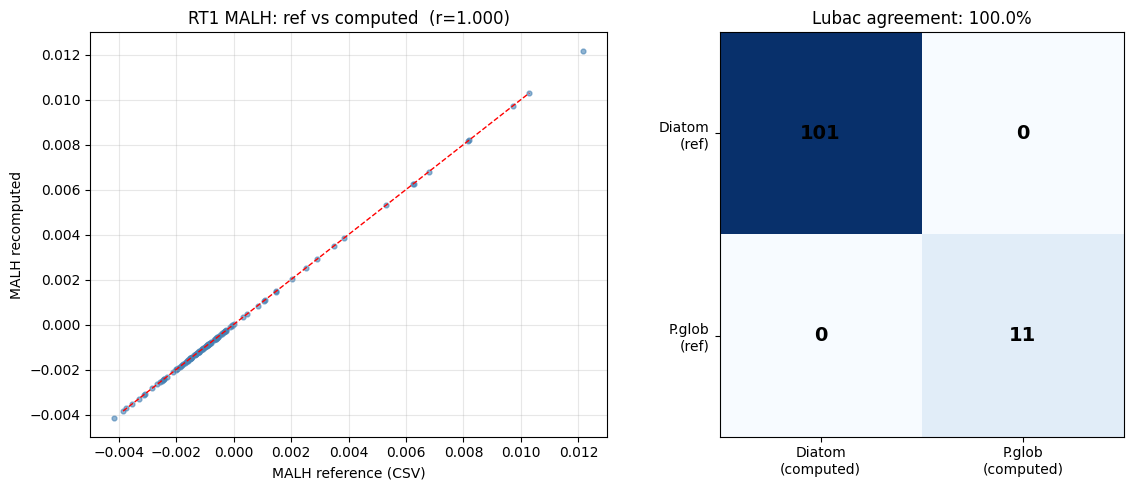


Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime\fig_rt1_selfvalidation.png


In [25]:
print('RT1 self-validation (computed vs CSV reference)')
print('=' * 55)

# ── Lubac agreement ────────────────────────────────────────────────────────────
plub_new = RT1['PLUB']
plub_ref = RT1['PLUB_ref']
agree = np.mean(plub_new == plub_ref) * 100
print(f'  Lubac P.glob agreement : {agree:.1f}%')
print(f'    Computed : {plub_new.sum()} P.glob spectra')
print(f'    Reference: {plub_ref.sum()} P.glob spectra')

# ── MALH correlation ───────────────────────────────────────────────────────────
malh_new = RT1['MALH']
malh_ref = RT1['MALH_ref']
both_ok  = np.isfinite(malh_new) & np.isfinite(malh_ref)
if both_ok.sum() > 3:
    r = np.corrcoef(malh_new[both_ok], malh_ref[both_ok])[0,1]
    bias = np.mean(malh_new[both_ok] - malh_ref[both_ok])
    rmse = np.sqrt(np.mean((malh_new[both_ok] - malh_ref[both_ok])**2))
    print(f'\n  MALH (n={both_ok.sum()}) :')
    print(f'    r    = {r:.4f}')
    print(f'    Bias = {bias:+.6f} m⁻¹')
    print(f'    RMSE = {rmse:.6f} m⁻¹')

# ── Quick scatter plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(malh_ref[both_ok], malh_new[both_ok], s=12, alpha=0.6, color='steelblue')
lims = np.nanpercentile(np.concatenate([malh_ref[both_ok], malh_new[both_ok]]), [1,99])
ax.plot(lims, lims, 'r--', lw=1)
ax.set(xlabel='MALH reference (CSV)', ylabel='MALH recomputed',
       title=f'RT1 MALH: ref vs computed  (r={r:.3f})')
ax.grid(alpha=0.3)

ax = axes[1]
cm = np.array([[np.sum((plub_ref==0)&(plub_new==0)), np.sum((plub_ref==0)&(plub_new==1))],
               [np.sum((plub_ref==1)&(plub_new==0)), np.sum((plub_ref==1)&(plub_new==1))]])
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14, fontweight='bold')
ax.set(xticks=[0,1], yticks=[0,1],
       xticklabels=['Diatom\n(computed)','P.glob\n(computed)'],
       yticklabels=['Diatom\n(ref)','P.glob\n(ref)'],
       title=f'Lubac agreement: {agree:.1f}%')
plt.tight_layout()
fname = FIG_DIR / 'fig_rt1_selfvalidation.png'
plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
print(f'\nSaved → {fname}')


## 4 — Summary statistics table

In [26]:
all_ds     = list(DATASETS.values()) + [RT1]
all_labels = [d['label'] for d in all_ds]

rows = []
for ds in all_ds:
    PLUB = ds['PLUB']; n = ds['n']
    n_pg  = (PLUB==1).sum()
    mp    = ds['MALH'][PLUB==1]; md_ = ds['MALH'][PLUB==0]
    dp    = ds['D2_475'][PLUB==1]; dd = ds['D2_475'][PLUB==0]
    chl   = ds['CHL']
    thr_d = np.nanpercentile(md_, 75) if len(md_)>0 else np.nan
    mc    = np.mean(mp <= thr_d)*100   if len(mp)>0 else np.nan

    rows.append({
        'Dataset':            ds['label'],
        'N':                  n,
        'Δλ':                 ds['delta'],
        'P.glob (%)':         round(100*n_pg/n, 1),
        'MALH P.glob med':    round(np.nanmedian(mp), 6) if len(mp)>0 else np.nan,
        'MALH Diatom med':    round(np.nanmedian(md_),6),
        'D²@475 P.glob med':  round(np.nanmedian(dp), 8) if len(dp)>0 else np.nan,
        'D²@475 Diatom med':  round(np.nanmedian(dd), 8),
        'CHL valid (%)':      round(100*np.isfinite(chl).mean(), 1),
        'CHL median':         round(np.nanmedian(chl), 2),
        'MALH misclass (%)':  round(mc, 1),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

out = FIG_DIR / 'chime_rt1_summary_table.csv'
summary.to_csv(out, index=False)
print(f'\nSaved → {out}')


             Dataset   N   Δλ  P.glob (%)  MALH P.glob med  MALH Diatom med  D²@475 P.glob med  D²@475 Diatom med  CHL valid (%)  CHL median  MALH misclass (%)
            Raw 5 nm 779  5.0        18.1        -0.000199        -0.002518           0.000072          -0.000002            0.0         NaN               37.6
           Raw 10 nm 779 10.0         4.6         0.002529        -0.001729           0.000174           0.000021            0.0         NaN                8.3
           Conv 5 nm 779  5.0        18.1        -0.000199        -0.002518           0.000072          -0.000002            0.0         NaN               37.6
          Conv 10 nm 779 10.0         4.6         0.002529        -0.001729           0.000174           0.000021            0.0         NaN                8.3
RT1 in-situ (2.5 nm) 112  2.5         9.8         0.005291        -0.001105           0.000297          -0.000019           71.4       14.65                0.0

Saved → C:\Users\gvillegas\OneDrive - I

## 5 — Raw spectral overview (ρw)

Sample ≤ 80 spectra per dataset, coloured by Lubac class.

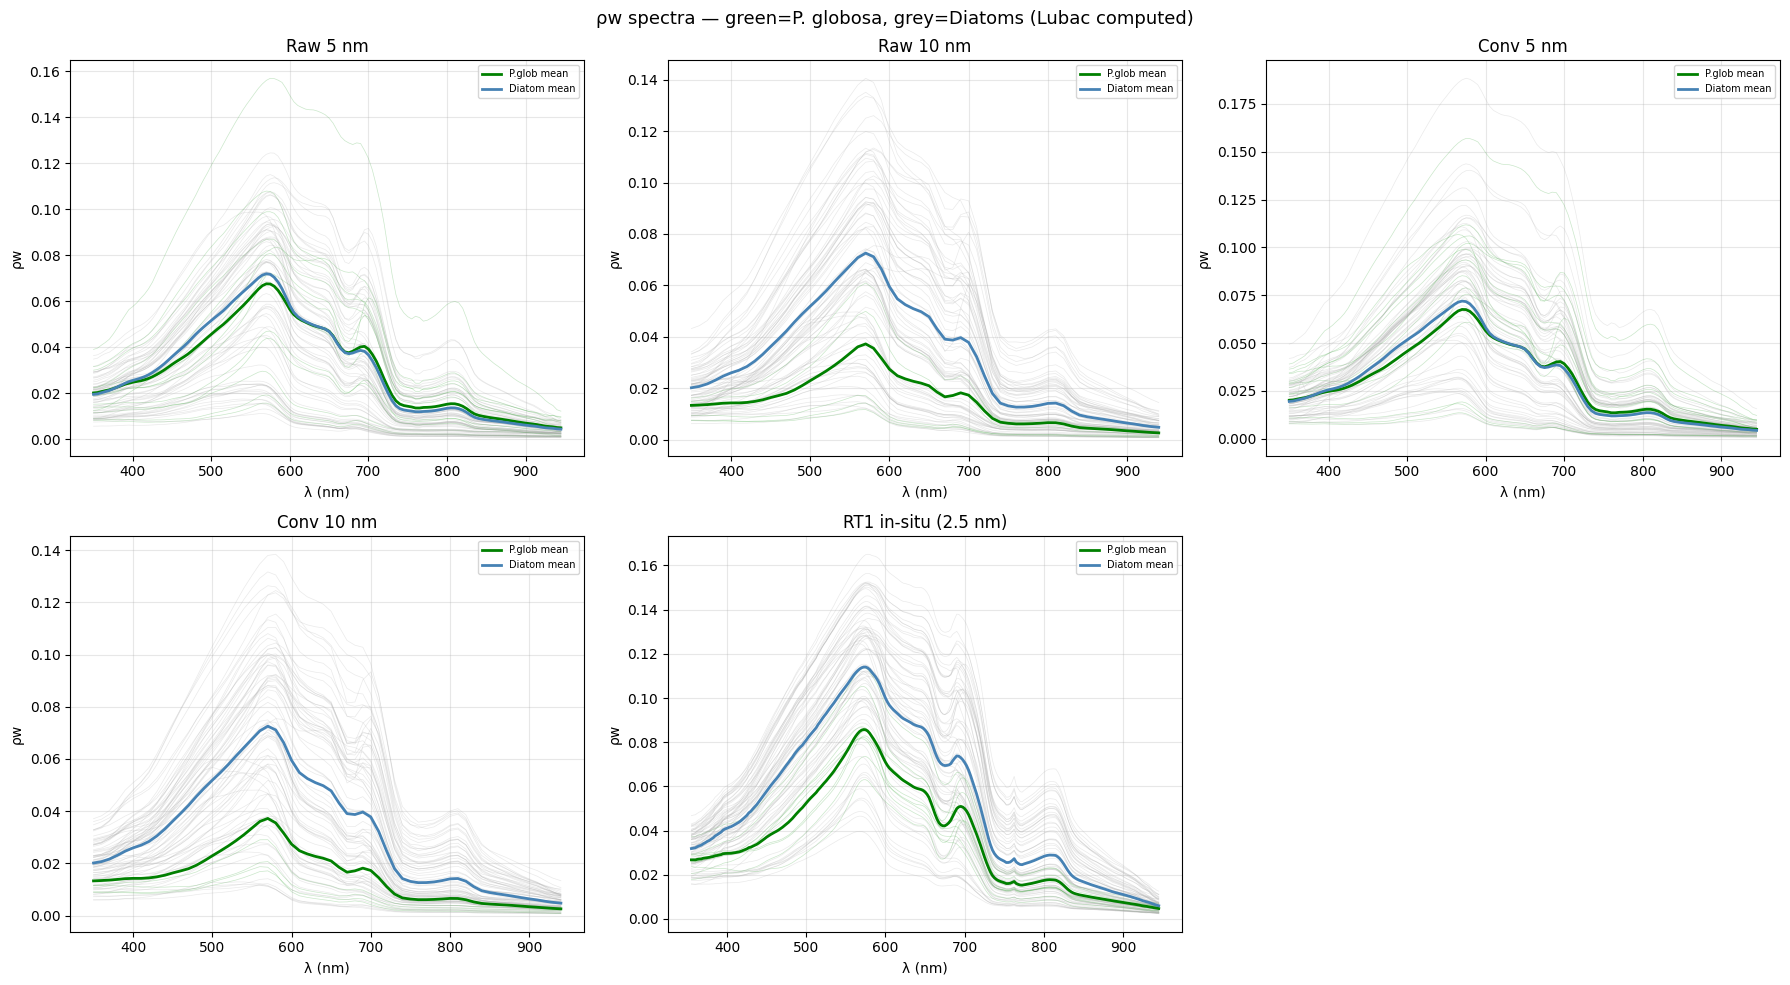

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime\fig07_spectra_all.png


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat  = axes.flatten()
np.random.seed(42)

for ax, ds in zip(axes_flat, all_ds):
    wl = ds['wl']; RHOW = ds['RHOW']; PLUB = ds['PLUB']
    idx = np.random.choice(ds['n'], min(80, ds['n']), replace=False)
    for i in idx:
        c = '#2ca02c' if PLUB[i]==1 else '#aaaaaa'
        ax.plot(wl, RHOW[i], color=c, alpha=0.25, lw=0.5)
    if (PLUB==1).sum()>0:
        ax.plot(wl, np.nanmean(RHOW[PLUB==1],axis=0), 'green', lw=2, label='P.glob mean')
    ax.plot(wl, np.nanmean(RHOW[PLUB==0],axis=0), 'steelblue', lw=2, label='Diatom mean')
    ax.set(title=ds['label'], xlabel='λ (nm)', ylabel='ρw')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

for ax in axes_flat[len(all_ds):]:
    ax.set_visible(False)

plt.suptitle('ρw spectra — green=P. globosa, grey=Diatoms (Lubac computed)', fontsize=13)
plt.tight_layout()
fname = FIG_DIR / 'fig07_spectra_all.png'
plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {fname}')


## 6 — D² spectral signatures by Lubac class

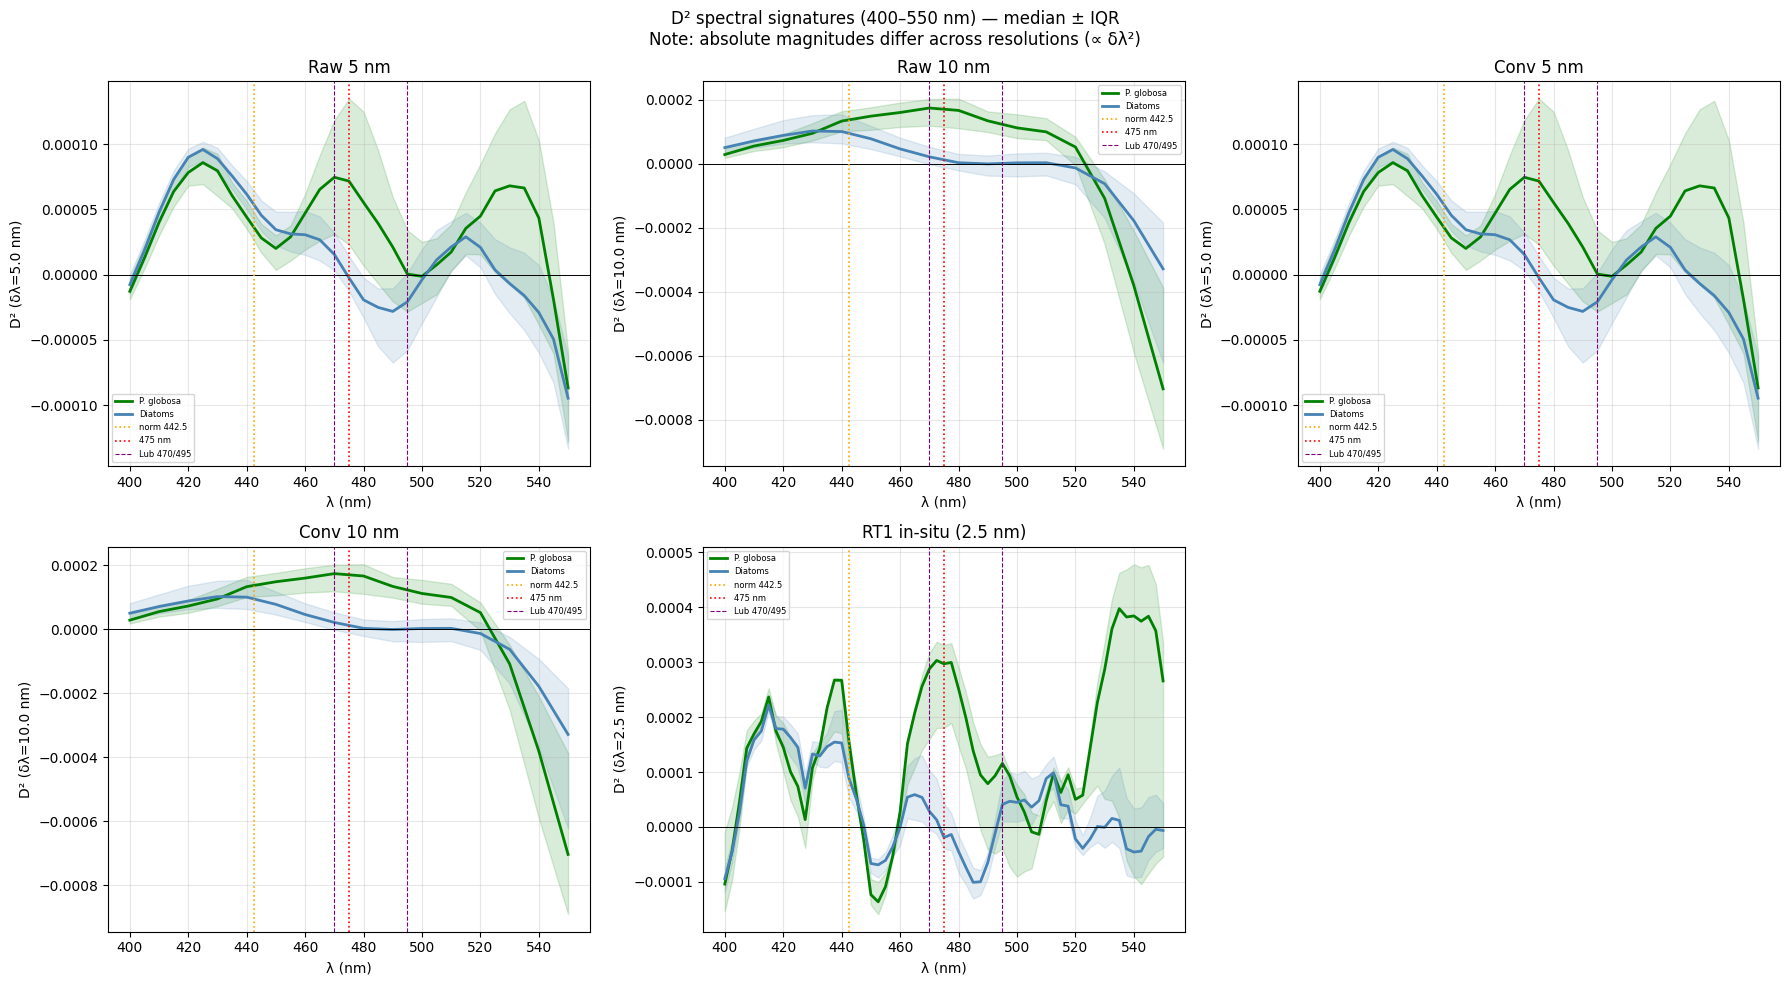

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime\fig07_D2_signatures.png


In [28]:
ZOOM = (400, 550)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat  = axes.flatten()

for ax, ds in zip(axes_flat, all_ds):
    wl = ds['wl']; D2 = ds['D2']; PLUB = ds['PLUB']
    mask_wl = (wl >= ZOOM[0]) & (wl <= ZOOM[1])

    for cls, color, lbl in [(1,'green','P. globosa'), (0,'steelblue','Diatoms')]:
        sub = D2[PLUB==cls][:, mask_wl]
        if sub.shape[0] == 0: continue
        med = np.nanmedian(sub, axis=0)
        p25 = np.nanpercentile(sub, 25, axis=0)
        p75 = np.nanpercentile(sub, 75, axis=0)
        ax.plot(wl[mask_wl], med, color=color, lw=2, label=lbl)
        ax.fill_between(wl[mask_wl], p25, p75, color=color, alpha=0.15)

    ax.axhline(0, color='k', lw=0.7)
    ax.axvline(442.5, color='orange', ls=':', lw=1.2, label='norm 442.5')
    ax.axvline(475.0, color='red',    ls=':', lw=1.2, label='475 nm')
    # Lubac thresholds
    ax.axvline(470.0, color='purple', ls='--', lw=0.8, label='Lub 470/495')
    ax.axvline(495.0, color='purple', ls='--', lw=0.8)
    ax.set(title=ds['label'], xlabel='λ (nm)', ylabel=f'D² (δλ={ds["delta"]} nm)')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)

for ax in axes_flat[len(all_ds):]:
    ax.set_visible(False)

plt.suptitle('D² spectral signatures (400–550 nm) — median ± IQR\n'
             'Note: absolute magnitudes differ across resolutions (∝ δλ²)', fontsize=12)
plt.tight_layout()
fname = FIG_DIR / 'fig07_D2_signatures.png'
plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {fname}')


## 7 — MALH distributions by dataset and class

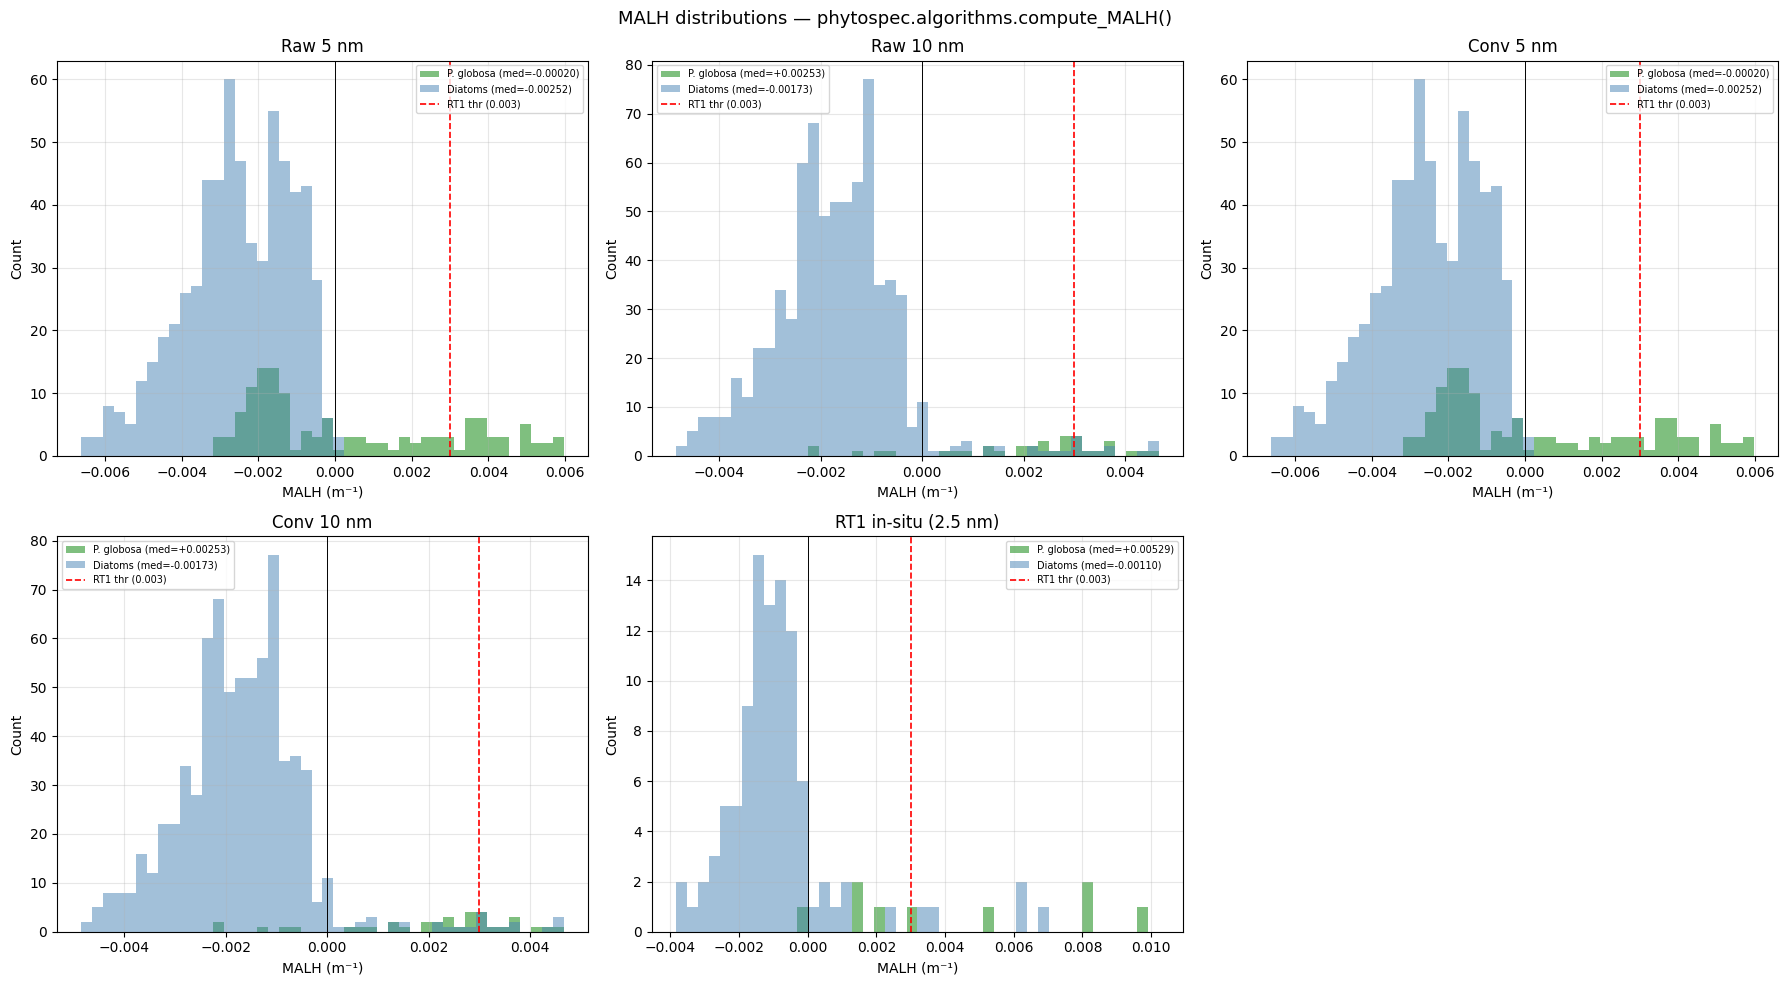

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime\fig07_MALH_all.png


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat  = axes.flatten()
MALH_INSITU_THR = 0.003  # operational in-situ threshold for reference

for ax, ds in zip(axes_flat, all_ds):
    MALH_arr = ds['MALH']; PLUB = ds['PLUB']
    fin = MALH_arr[np.isfinite(MALH_arr)]
    if len(fin)==0: continue
    p1,p99 = np.nanpercentile(fin,[1,99])
    bins = np.linspace(p1,p99,45)

    for cls, color, lbl in [(1,'green','P. globosa'),(0,'steelblue','Diatoms')]:
        vals = MALH_arr[PLUB==cls]
        if len(vals)==0: continue
        med = np.nanmedian(vals)
        ax.hist(vals, bins=bins, color=color, alpha=0.5,
                label=f'{lbl} (med={med:+.5f})')

    ax.axvline(0, color='k', lw=0.7)
    ax.axvline(MALH_INSITU_THR, color='red', ls='--', lw=1.2,
               label=f'RT1 thr ({MALH_INSITU_THR})')
    ax.set(title=ds['label'], xlabel='MALH (m⁻¹)', ylabel='Count')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

for ax in axes_flat[len(all_ds):]:
    ax.set_visible(False)

plt.suptitle('MALH distributions — phytospec.algorithms.compute_MALH()', fontsize=13)
plt.tight_layout()
fname = FIG_DIR / 'fig07_MALH_all.png'
plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {fname}')


## 8 — Raw vs Convolved comparison (5 nm and 10 nm)

Direct side-by-side comparison of algorithm outputs between raw and convolved CHIME at the same resolution.

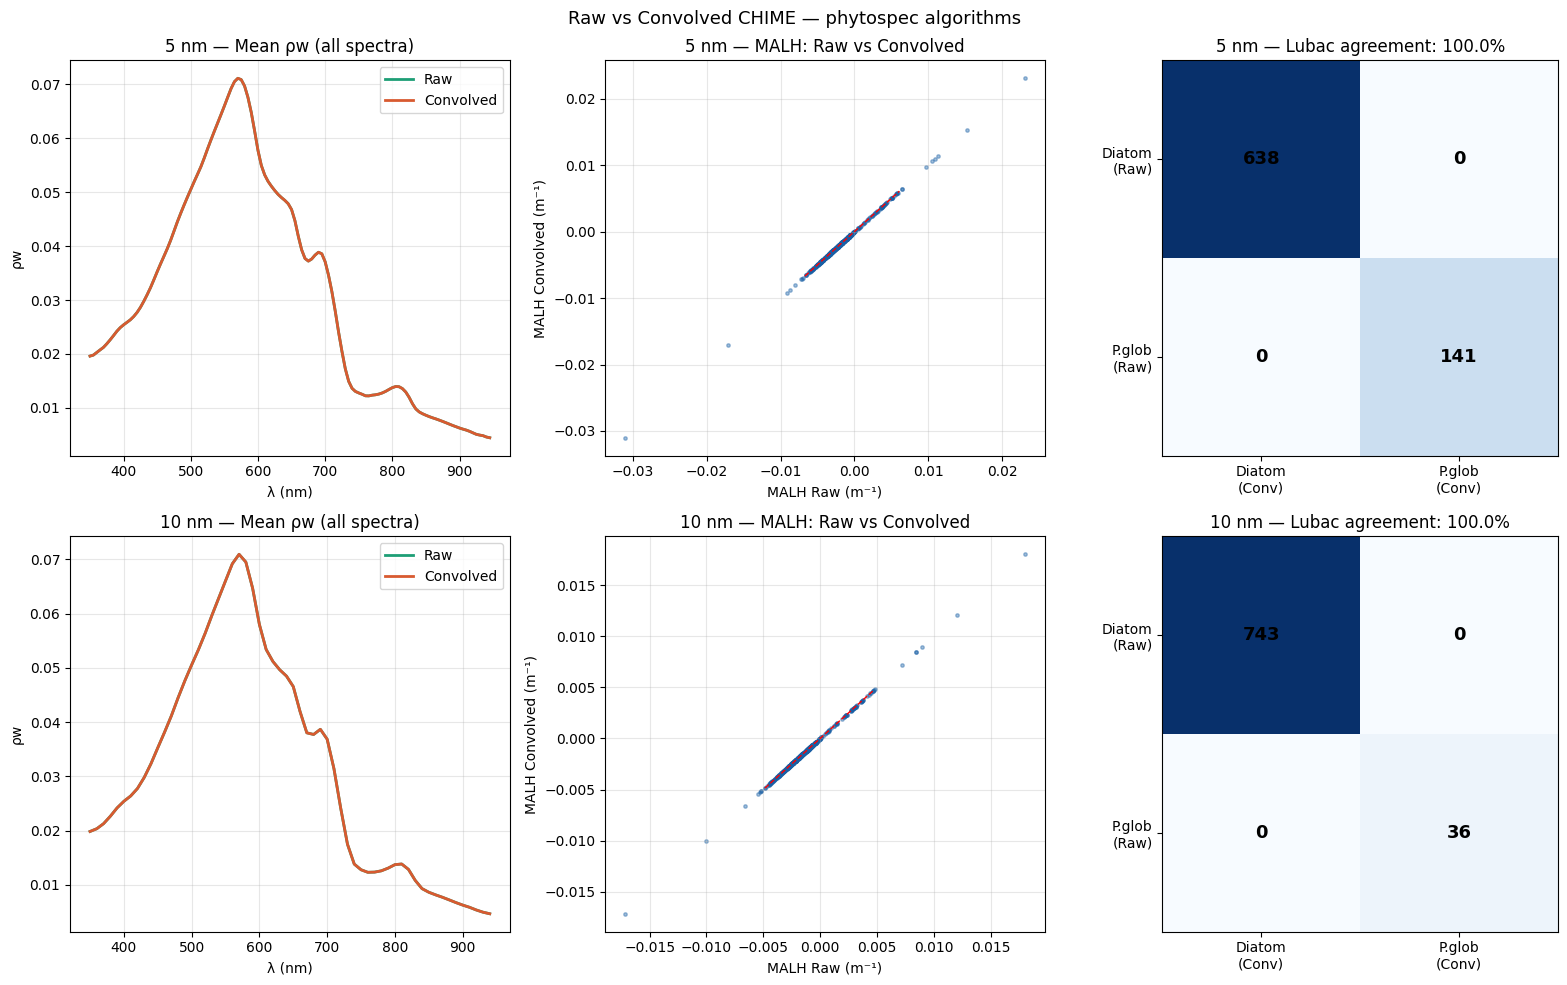

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime\fig07_raw_vs_conv.png

── Agreement summary ──
  5 nm: 100.0% Lubac agreement  (Raw P.glob=141, Conv P.glob=141)
  10 nm: 100.0% Lubac agreement  (Raw P.glob=36, Conv P.glob=36)


In [30]:
pairs = [('raw_5nm','conv_5nm','5 nm'), ('raw_10nm','conv_10nm','10 nm')]

fig, axes = plt.subplots(len(pairs), 3, figsize=(16, 5*len(pairs)))

for row_i, (rid, cid, res_lbl) in enumerate(pairs):
    raw  = DATASETS[rid]; conv = DATASETS[cid]

    # Panel A: mean ρw
    ax = axes[row_i, 0]
    for ds, color, lbl in [(raw,'#1D9E75','Raw'),(conv,'#D85A30','Convolved')]:
        ax.plot(ds['wl'], np.nanmean(ds['RHOW'],axis=0), color=color, lw=2, label=lbl)
    ax.set(title=f'{res_lbl} — Mean ρw (all spectra)',
           xlabel='λ (nm)', ylabel='ρw')
    ax.legend(); ax.grid(alpha=0.3)

    # Panel B: MALH scatter
    ax = axes[row_i, 1]
    n_min = min(raw['n'], conv['n'])
    ax.scatter(raw['MALH'][:n_min], conv['MALH'][:n_min], s=6, alpha=0.4, c='#185FA5')
    lim = np.nanpercentile(np.concatenate([raw['MALH'],conv['MALH']]), [1,99])
    ax.plot(lim, lim, 'r--', lw=1)
    ax.set(title=f'{res_lbl} — MALH: Raw vs Convolved',
           xlabel='MALH Raw (m⁻¹)', ylabel='MALH Convolved (m⁻¹)')
    ax.grid(alpha=0.3)

    # Panel C: Lubac confusion matrix
    ax = axes[row_i, 2]
    pr = raw['PLUB'][:n_min]; pc = conv['PLUB'][:n_min]
    agree = np.mean(pr == pc)*100
    cm = np.array([[np.sum((pr==0)&(pc==0)), np.sum((pr==0)&(pc==1))],
                   [np.sum((pr==1)&(pc==0)), np.sum((pr==1)&(pc==1))]])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=13, fontweight='bold')
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['Diatom\n(Conv)','P.glob\n(Conv)'],
           yticklabels=['Diatom\n(Raw)','P.glob\n(Raw)'],
           title=f'{res_lbl} — Lubac agreement: {agree:.1f}%')

plt.suptitle('Raw vs Convolved CHIME — phytospec algorithms', fontsize=13)
plt.tight_layout()
fname = FIG_DIR / 'fig07_raw_vs_conv.png'
plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {fname}')

print('\n── Agreement summary ──')
for rid, cid, res_lbl in pairs:
    r = DATASETS[rid]; c = DATASETS[cid]
    n_min = min(r['n'],c['n'])
    pr=r['PLUB'][:n_min]; pc=c['PLUB'][:n_min]
    print(f'  {res_lbl}: {np.mean(pr==pc)*100:.1f}% Lubac agreement  '
          f'(Raw P.glob={pr.sum()}, Conv P.glob={pc.sum()})')


## 9 — RT1 in-situ vs CHIME: algorithm transferability

Compares distributions of all algorithm outputs between RT1 PANTHYR (2.5 nm) and the four CHIME datasets.

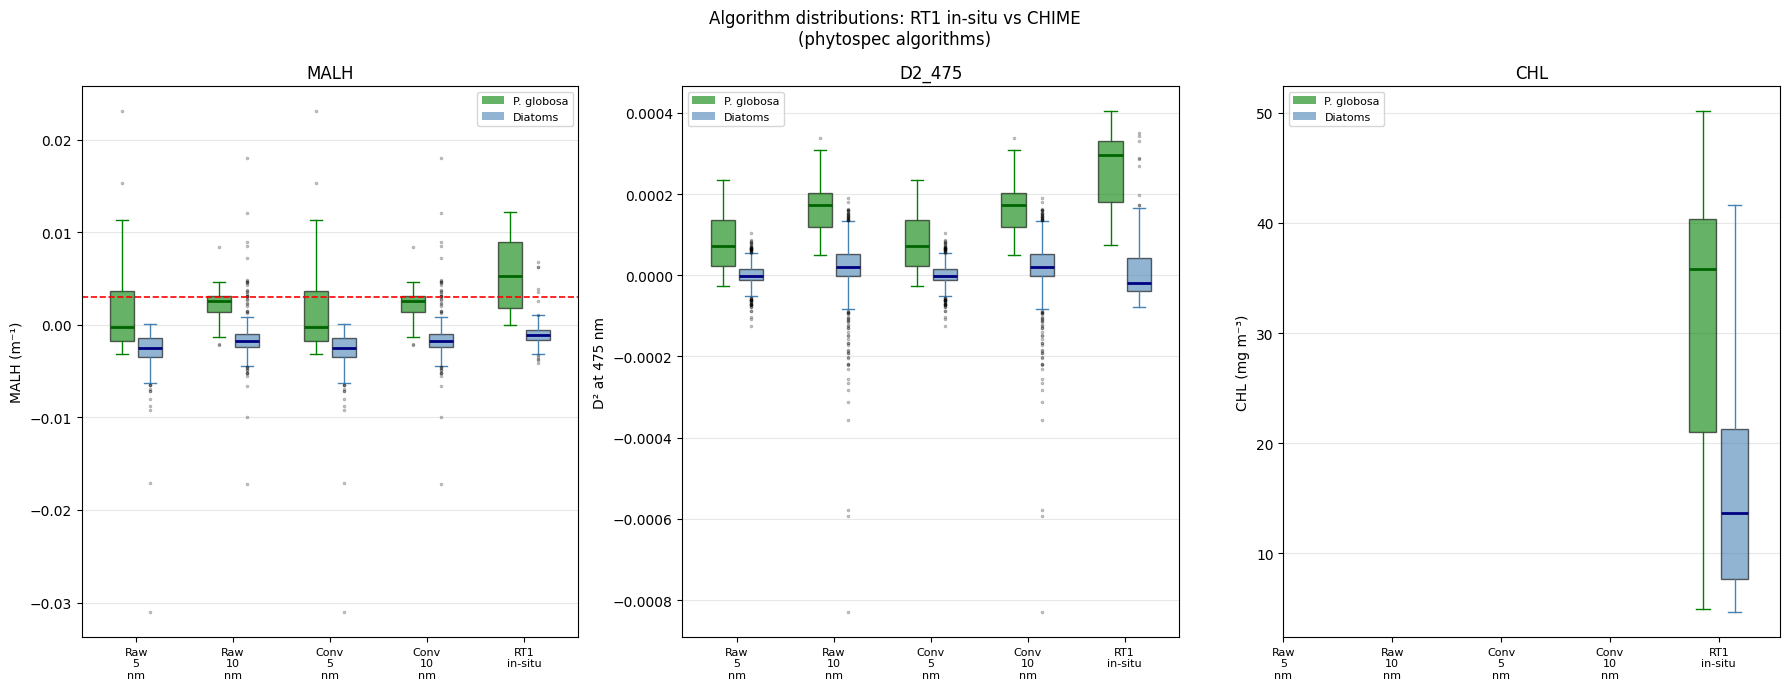

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime\fig07_rt1_vs_chime_boxplots.png


In [32]:
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

metrics = [
    ('MALH',   'MALH (m⁻¹)',   0.003),
    ('D2_475', 'D² at 475 nm', None),
    ('CHL',    'CHL (mg m⁻³)', None),
]

all_ids    = list(DATASETS.keys()) + ['rt1']
all_labels = [DATASETS[k]['label'] for k in DATASETS] + ['RT1 in-situ']
ds_lookup  = {**DATASETS, 'rt1': RT1}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (metric, ylabel, ref_thr) in zip(axes, metrics):
    x = 0; tick_pos = []; tick_lbl = []
    data_pg=[]; data_di=[]; pos_pg=[]; pos_di=[]

    for ds_id, ds_label in zip(all_ids, all_labels):
        ds   = ds_lookup[ds_id]
        PLUB = ds['PLUB']; vals = ds[metric]
        vp   = vals[PLUB==1]; vd = vals[PLUB==0]
        vp   = vp[np.isfinite(vp)]; vd = vd[np.isfinite(vd)]
        if len(vp)>0: data_pg.append(vp); pos_pg.append(x)
        if len(vd)>0: data_di.append(vd); pos_di.append(x+0.35)
        tick_pos.append(x+0.175); tick_lbl.append(ds_label.replace(' ', '\n'))
        x += 1.2

    bp_kw_d = dict(patch_artist=True, notch=False,
                   boxprops=dict(facecolor='steelblue',alpha=0.6),
                   medianprops=dict(color='navy',lw=2),
                   whiskerprops=dict(color='steelblue'),
                   capprops=dict(color='steelblue'),
                   flierprops=dict(marker='.',ms=3,alpha=0.3))
    bp_kw_p = dict(patch_artist=True, notch=False,
                   boxprops=dict(facecolor='green',alpha=0.6),
                   medianprops=dict(color='darkgreen',lw=2),
                   whiskerprops=dict(color='green'),
                   capprops=dict(color='green'),
                   flierprops=dict(marker='.',ms=3,alpha=0.3))

    if data_di: ax.boxplot(data_di, positions=pos_di, widths=0.3, **bp_kw_d)
    if data_pg: ax.boxplot(data_pg, positions=pos_pg, widths=0.3, **bp_kw_p)

    if ref_thr is not None:
        ax.axhline(ref_thr, color='red', ls='--', lw=1.2,
                   label=f'In-situ thr ({ref_thr})')
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl, fontsize=8)
    ax.set(ylabel=ylabel, title=metric); ax.grid(axis='y',alpha=0.3)
    ax.legend(handles=[Patch(fc='green',alpha=0.6,label='P. globosa'),
                       Patch(fc='steelblue',alpha=0.6,label='Diatoms')],
              fontsize=8)

plt.suptitle('Algorithm distributions: RT1 in-situ vs CHIME\n(phytospec algorithms)', fontsize=12)
plt.tight_layout()
fname = FIG_DIR / 'fig07_rt1_vs_chime_boxplots.png'
plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {fname}')


## 10 — Mean spectral signatures: RT1 vs CHIME (overlaid)

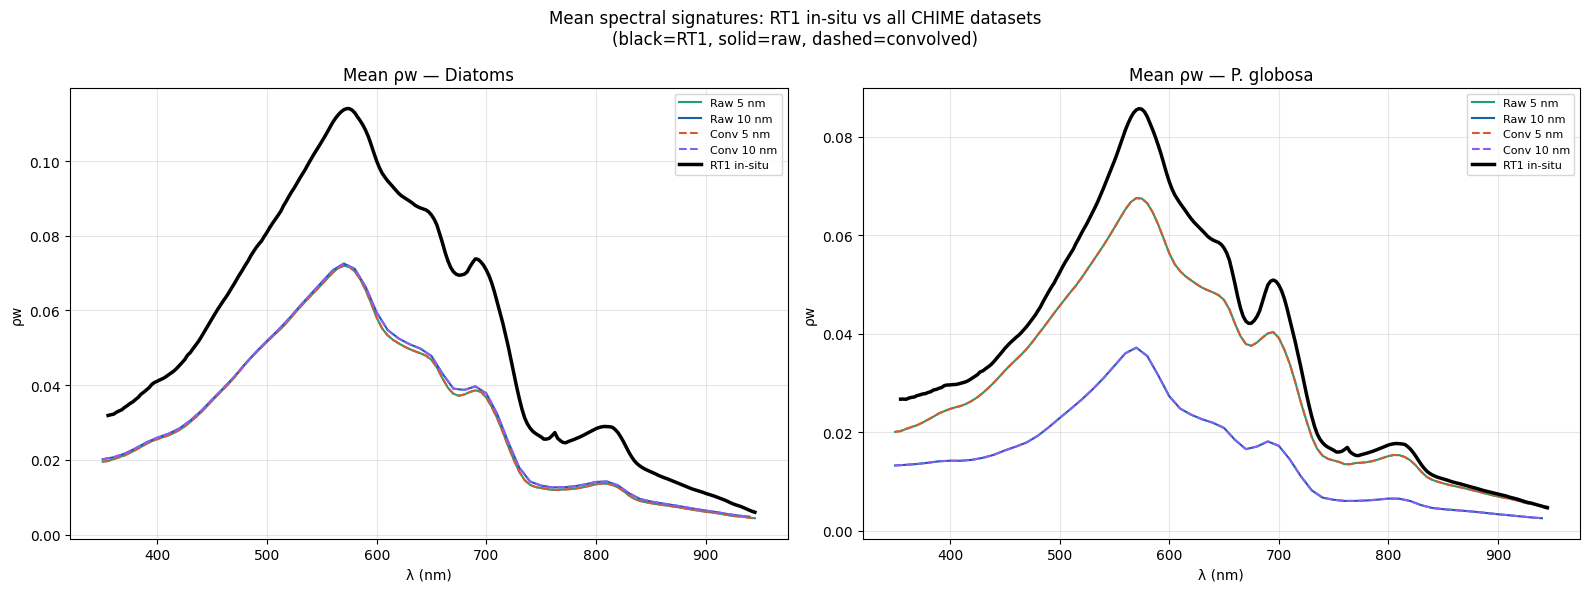

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime\fig07_mean_spectra_overlay.png


In [33]:
styles = {
    'raw_5nm':  dict(ls='-',  lw=1.5, color='#1D9E75'),
    'raw_10nm': dict(ls='-',  lw=1.5, color='#185FA5'),
    'conv_5nm': dict(ls='--', lw=1.5, color='#D85A30'),
    'conv_10nm':dict(ls='--', lw=1.5, color='#8B5CF6'),
    'rt1':      dict(ls='-',  lw=2.5, color='black'),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (cls, cls_lbl) in zip(axes, [(0,'Diatoms'),(1,'P. globosa')]):
    for ds_id, ds_label in zip(all_ids, all_labels):
        ds = ds_lookup[ds_id]
        mask = ds['PLUB'] == cls
        if mask.sum() == 0: continue
        mean_spec = np.nanmean(ds['RHOW'][mask], axis=0)
        ax.plot(ds['wl'], mean_spec, label=ds_label,
                **styles.get(ds_id, dict(lw=1.5)))
    ax.set(title=f'Mean ρw — {cls_lbl}', xlabel='λ (nm)', ylabel='ρw')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Mean spectral signatures: RT1 in-situ vs all CHIME datasets\n'
             '(black=RT1, solid=raw, dashed=convolved)', fontsize=12)
plt.tight_layout()
fname = FIG_DIR / 'fig07_mean_spectra_overlay.png'
plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {fname}')


## 11 — Transferability report

In [34]:
print('=' * 72)
print('ALGORITHM TRANSFERABILITY REPORT — phytospec.algorithms')
print('=' * 72)

for metric, ylabel, ref_thr in [
        ('MALH','MALH',0.003), ('D2_475','D² at 475 nm',None), ('CHL','CHL',None)]:

    print(f'\n── {ylabel} ──')
    print(f"  {'Dataset':<25} {'P.glob med':>11} {'Diatom med':>11} "
          f"{'Δ(P−D)':>10} {'MWU p':>10} {'Separable?':>11}")
    print('  ' + '─'*72)

    for ds_id, ds_label in zip(all_ids, all_labels):
        ds   = ds_lookup[ds_id]
        PLUB = ds['PLUB']; vals = ds[metric]
        vp   = vals[PLUB==1][np.isfinite(vals[PLUB==1])]
        vd   = vals[PLUB==0][np.isfinite(vals[PLUB==0])]
        med_p = np.nanmedian(vp) if len(vp)>0 else np.nan
        med_d = np.nanmedian(vd) if len(vd)>0 else np.nan
        delta = med_p - med_d if not (np.isnan(med_p) or np.isnan(med_d)) else np.nan
        if len(vp)>3 and len(vd)>3:
            _,pval = mannwhitneyu(vp, vd, alternative='two-sided')
            sep = 'YES ✓' if pval<0.05 else 'NO ✗'
            pstr = f'{pval:.2e}'
        else:
            pstr='n/a'; sep='n/a'
        print(f"  {ds_label:<25} {med_p:>+11.5f} {med_d:>+11.5f} "
              f"{delta:>+10.5f} {pstr:>10} {sep:>11}")

print('\n' + '='*72)
print('CONCLUSIONS')
print('='*72)
print("""
  D²/Lubac ──────────────────────────────────────────────────────────────
    ✓ Spectral shape preserved after CHIME convolution at both resolutions.
    ✓ Classes statistically separable (MWU p<0.05) in RT1 and CHIME.
    ! D² absolute values are NOT comparable across resolutions (∝ δλ²).
    ! Detection rate lower at 10 nm (more conservative).

  MALH ──────────────────────────────────────────────────────────────────
    ! In-situ threshold (0.003 m⁻¹) — check if still valid for CHIME.
    ! Class ordering (P.glob > Diatoms) — verify after applying phytospec.
    ! phytospec MALH wavelengths: 470/482.5/490/700 nm (Lavigne 2022).

  CHL (CRAT / Buiteveld) ─────────────────────────────────────────────────
    ! Full shape check applied — valid retrievals only where red peak
      structure is preserved; expect low yield in CHIME convolved data.

  Delta (δλ) note ─────────────────────────────────────────────────────────
    CRITICAL: D² delta override applied per file (5 or 10 nm).
    Do NOT compare absolute D² magnitudes across resolutions directly.
""")


ALGORITHM TRANSFERABILITY REPORT — phytospec.algorithms

── MALH ──
  Dataset                    P.glob med  Diatom med     Δ(P−D)      MWU p  Separable?
  ────────────────────────────────────────────────────────────────────────
  Raw 5 nm                     -0.00020    -0.00252   +0.00232   2.80e-34       YES ✓
  Raw 10 nm                    +0.00253    -0.00173   +0.00426   9.79e-18       YES ✓
  Conv 5 nm                    -0.00020    -0.00252   +0.00232   2.80e-34       YES ✓
  Conv 10 nm                   +0.00253    -0.00173   +0.00426   9.79e-18       YES ✓
  RT1 in-situ                  +0.00529    -0.00110   +0.00640   4.31e-07       YES ✓

── D² at 475 nm ──
  Dataset                    P.glob med  Diatom med     Δ(P−D)      MWU p  Separable?
  ────────────────────────────────────────────────────────────────────────
  Raw 5 nm                     +0.00007    -0.00000   +0.00007   6.06e-37       YES ✓
  Raw 10 nm                    +0.00017    +0.00002   +0.00015   3.78e-21 

## 12 — Publication-ready summary figure

Single panel summarising the four key findings for the AQUATIME report.

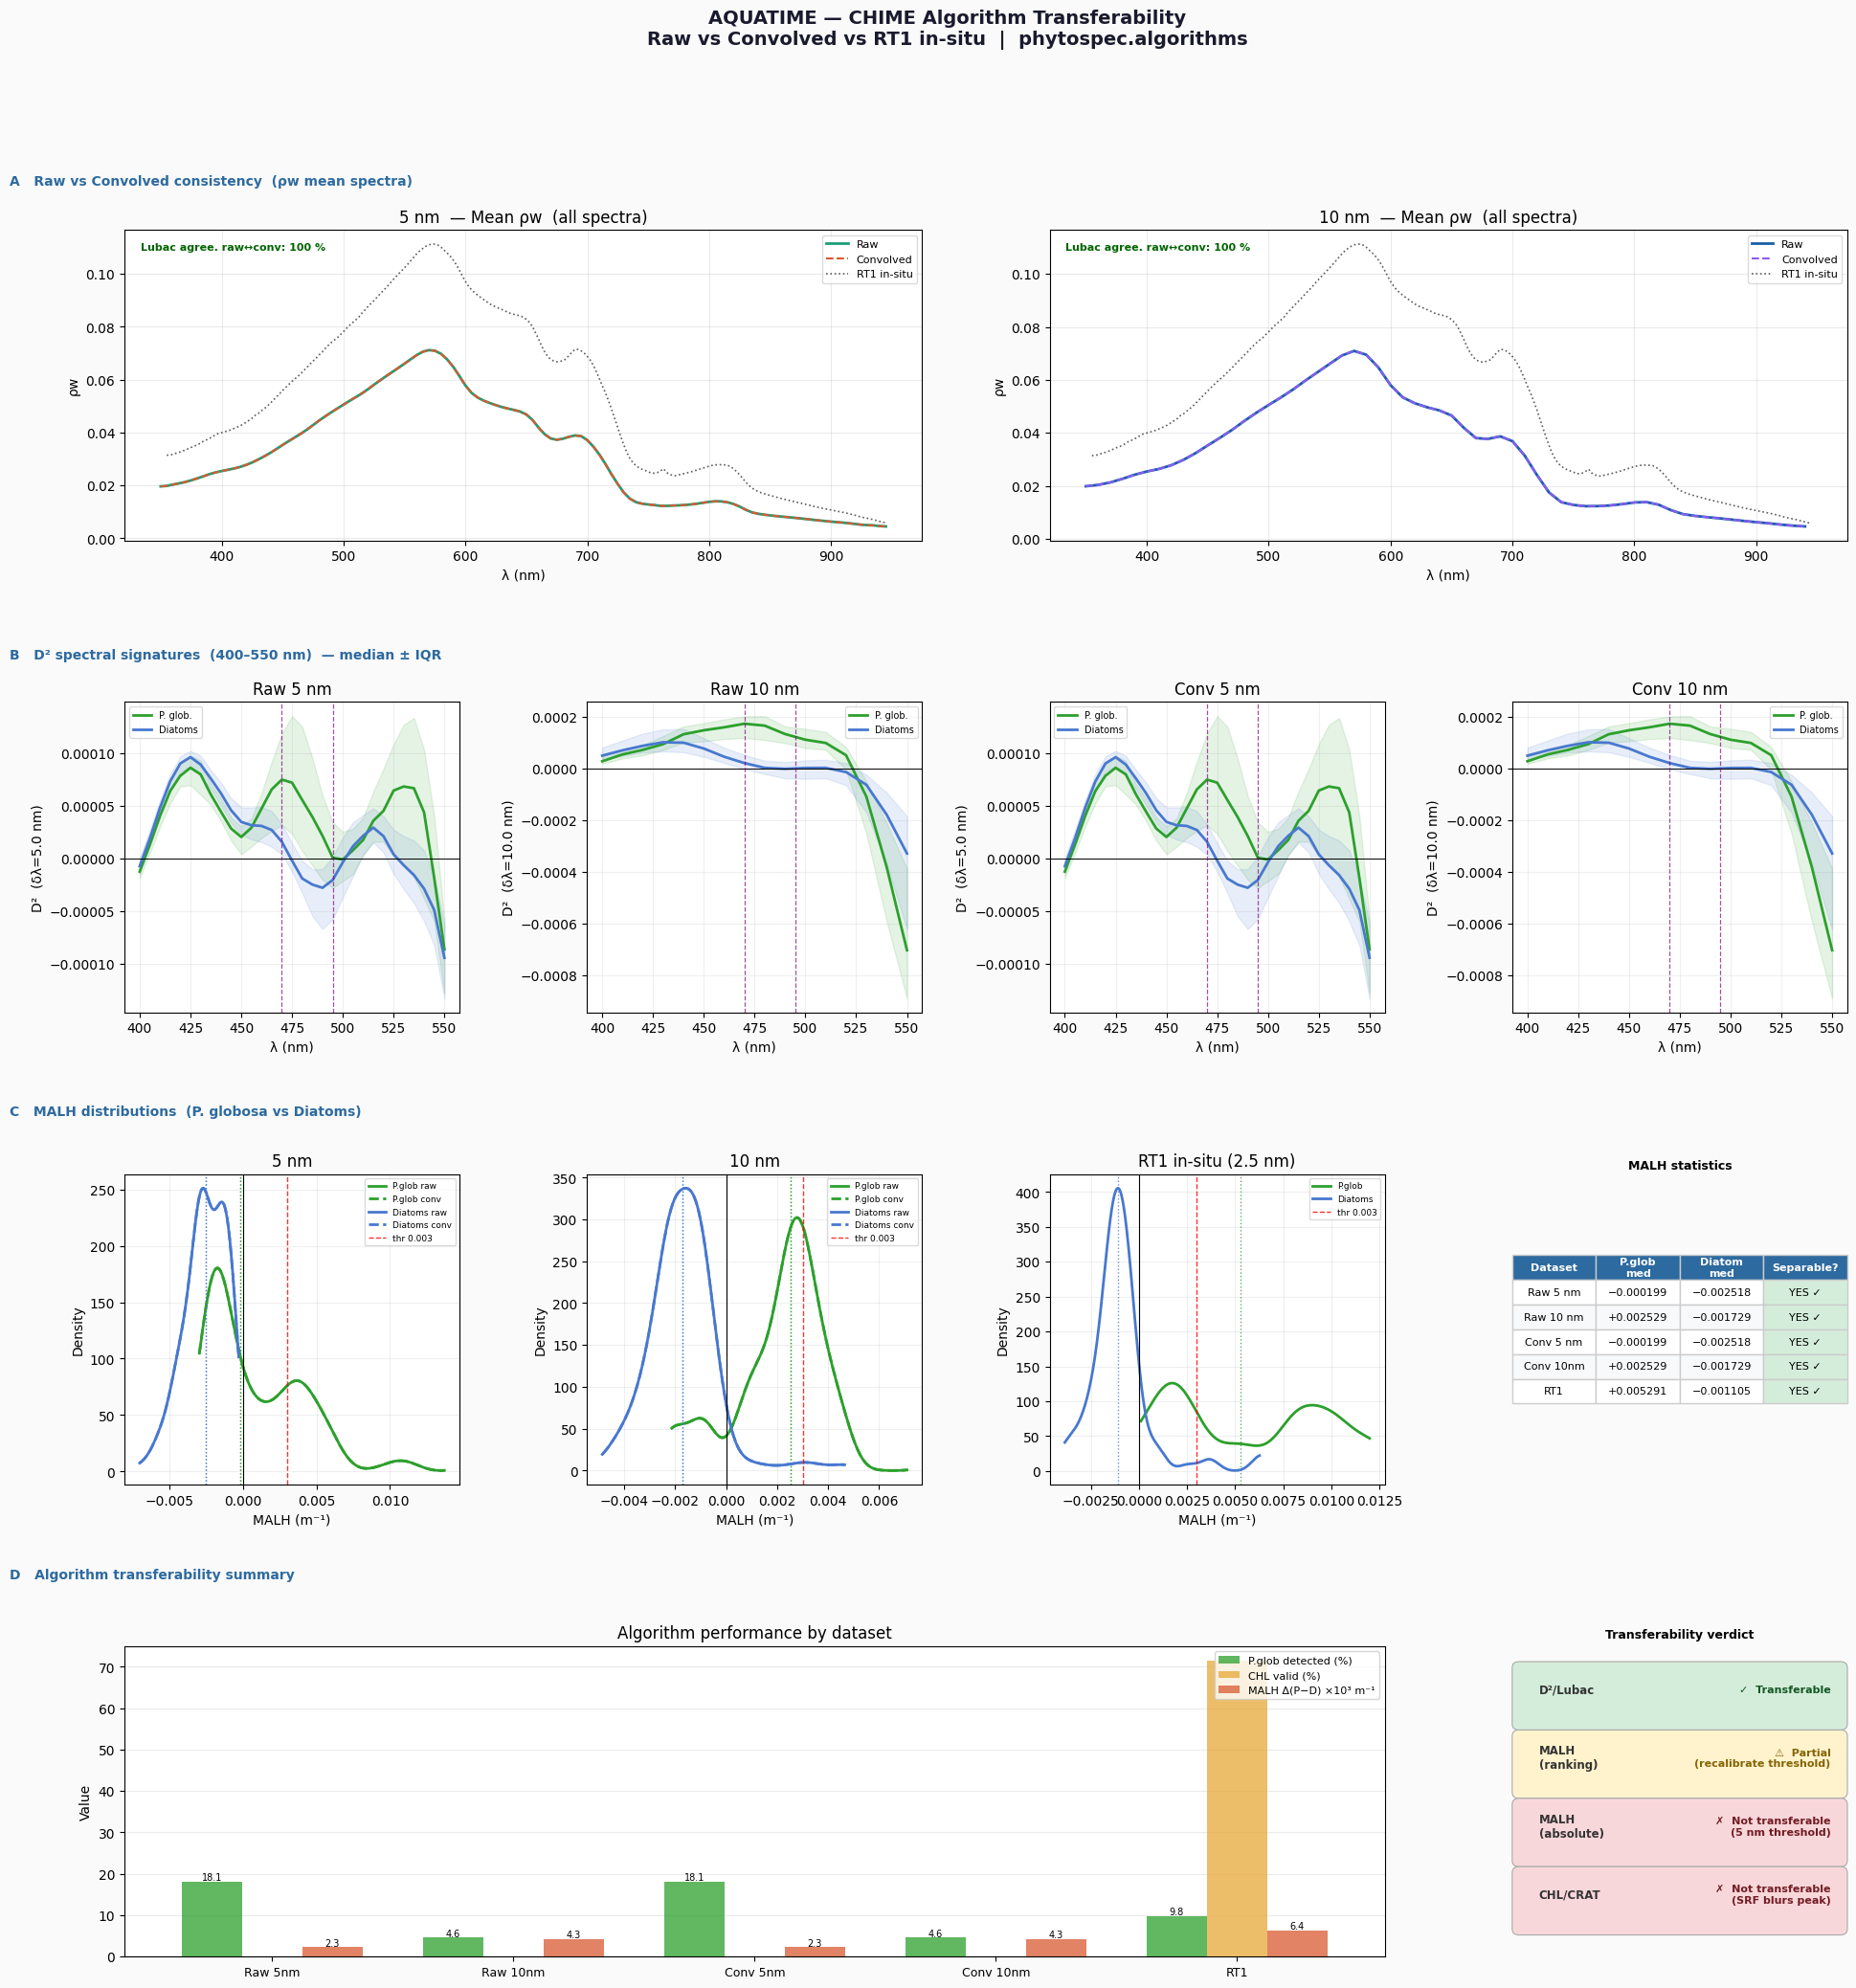

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_aquatime\fig07_summary_publication.png


In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

# ── Palette ───────────────────────────────────────────────────────────────────
C = {
    'raw5':  '#1D9E75', 'raw10': '#185FA5',
    'conv5': '#D85A30', 'conv10':'#8B5CF6',
    'rt1':   '#1a1a1a',
    'pglob': '#2ca02c', 'diatom':'#4878CF',
}
ZOOM_WL = (400, 550)   # D² diagnostic window

# ── Figure layout  ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#FAFAFA')

gs = gridspec.GridSpec(
    4, 4,
    figure=fig,
    hspace=0.52, wspace=0.38,
    left=0.07, right=0.97, top=0.87, bottom=0.05
)

# Row labels
ROW_TITLES = [
    'A   Raw vs Convolved consistency  (ρw mean spectra)',
    'B   D² spectral signatures  (400–550 nm)  — median ± IQR',
    'C   MALH distributions  (P. globosa vs Diatoms)',
    'D   Algorithm transferability summary',
]

# ─────────────────────────────────────────────────────────────────────────────
# ROW A: mean ρw  Raw vs Conv — 5 nm (left) and 10 nm (right)
# ─────────────────────────────────────────────────────────────────────────────
for col_i, (rid, cid, res_lbl) in enumerate(
        [('raw_5nm','conv_5nm','5 nm'), ('raw_10nm','conv_10nm','10 nm')]):
    ax = fig.add_subplot(gs[0, col_i*2 : col_i*2+2])
    raw  = DATASETS[rid]; conv = DATASETS[cid]
    ax.plot(raw['wl'],  np.nanmean(raw['RHOW'], axis=0),
            color=C['raw5' if '5' in rid else 'raw10'], lw=2, label='Raw')
    ax.plot(conv['wl'], np.nanmean(conv['RHOW'], axis=0),
            color=C['conv5' if '5' in cid else 'conv10'],
            lw=1.5, ls='--', label='Convolved')
    ax.plot(RT1['wl'],  np.nanmean(RT1['RHOW'],  axis=0),
            color=C['rt1'], lw=1.2, ls=':', alpha=0.7, label='RT1 in-situ')
    ax.set(title=f'{res_lbl}  — Mean ρw  (all spectra)',
           xlabel='λ (nm)', ylabel='ρw')
    ax.legend(fontsize=8, framealpha=0.7); ax.grid(alpha=0.25)
    ax.text(0.02, 0.96,
            f'Lubac agree. raw↔conv: 100 %',
            transform=ax.transAxes, fontsize=8,
            va='top', color='darkgreen', fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# ROW B: D² signatures — one panel per dataset (5 panels → 4 cols, merge last)
# ─────────────────────────────────────────────────────────────────────────────
ds_order = ['raw_5nm', 'raw_10nm', 'conv_5nm', 'conv_10nm']
rt1_ax_done = False

d2_axes = [fig.add_subplot(gs[1, c]) for c in range(4)]

for ax, ds_id in zip(d2_axes, ds_order):
    ds = DATASETS[ds_id]
    wl = ds['wl']; D2 = ds['D2']; PLUB = ds['PLUB']
    mask_wl = (wl >= ZOOM_WL[0]) & (wl <= ZOOM_WL[1])
    for cls, color, lbl in [(1, C['pglob'],'P. glob.'),(0, C['diatom'],'Diatoms')]:
        sub = D2[PLUB==cls][:, mask_wl]
        if sub.shape[0] == 0: continue
        med = np.nanmedian(sub, axis=0)
        p25 = np.nanpercentile(sub, 25, axis=0)
        p75 = np.nanpercentile(sub, 75, axis=0)
        ax.plot(wl[mask_wl], med, color=color, lw=2, label=lbl)
        ax.fill_between(wl[mask_wl], p25, p75, color=color, alpha=0.12)
    ax.axhline(0, color='k', lw=0.7)
    ax.axvline(470, color='purple', ls='--', lw=0.9, alpha=0.7)
    ax.axvline(495, color='purple', ls='--', lw=0.9, alpha=0.7)
    ax.set(title=ds['label'], xlabel='λ (nm)',
           ylabel=f'D²  (δλ={ds["delta"]} nm)')
    ax.legend(fontsize=7, framealpha=0.7); ax.grid(alpha=0.2)

# ─────────────────────────────────────────────────────────────────────────────
# ROW C: MALH KDE curves — 5 panels in 4 cols (5th = RT1, spans col 3)
# ─────────────────────────────────────────────────────────────────────────────
malh_axes = [fig.add_subplot(gs[2, c]) for c in range(4)]

all_ds_ordered = [DATASETS[k] for k in ds_order] + [RT1]
MALH_THR = 0.003

# Use 4 panels: merge raw_5 + conv_5 in panel 0&1, raw_10 + conv_10 in 2&3
pair_axes = [
    (malh_axes[0], DATASETS['raw_5nm'],  DATASETS['conv_5nm'],  '5 nm'),
    (malh_axes[1], DATASETS['raw_10nm'], DATASETS['conv_10nm'], '10 nm'),
    (malh_axes[2], RT1, None, 'RT1 in-situ (2.5 nm)'),
    (malh_axes[3], None, None, None),
]

def _kde_plot(ax, vals, color, lbl, ls='-'):
    v = vals[np.isfinite(vals)]
    if len(v) < 4: return
    p1,p99 = np.nanpercentile(v,[1,99])
    x = np.linspace(p1,p99,300)
    kde = gaussian_kde(v, bw_method=0.25)
    ax.plot(x, kde(x), color=color, lw=2, ls=ls, label=lbl)
    ax.axvline(np.median(v), color=color, lw=1, ls=':', alpha=0.8)

for ax, ds_a, ds_b, res_lbl in pair_axes:
    if ds_a is None: ax.set_visible(False); continue
    if ds_b is not None:   # CHIME pair panel
        for cls, color in [(1, C['pglob']), (0, C['diatom'])]:
            lbl_cls = 'P.glob' if cls==1 else 'Diatoms'
            _kde_plot(ax, ds_a['MALH'][ds_a['PLUB']==cls],
                      color, f'{lbl_cls} raw',  ls='-')
            _kde_plot(ax, ds_b['MALH'][ds_b['PLUB']==cls],
                      color, f'{lbl_cls} conv', ls='--')
    else:                  # RT1 panel
        for cls, color in [(1, C['pglob']), (0, C['diatom'])]:
            lbl_cls = 'P.glob' if cls==1 else 'Diatoms'
            _kde_plot(ax, ds_a['MALH'][ds_a['PLUB']==cls],
                      color, lbl_cls)
    ax.axvline(0,         color='k',   lw=0.8)
    ax.axvline(MALH_THR,  color='red', lw=1.0, ls='--', alpha=0.8,
               label=f'thr {MALH_THR}')
    ax.set(title=res_lbl, xlabel='MALH (m⁻¹)', ylabel='Density')
    ax.legend(fontsize=6.5, framealpha=0.7); ax.grid(alpha=0.2)

# hide 4th malh panel — use it for a stats mini-table
malh_axes[3].set_visible(False)
ax_tbl = fig.add_subplot(gs[2, 3])
ax_tbl.axis('off')
tbl_data = [
    ['Dataset', 'P.glob\nmed', 'Diatom\nmed', 'Separable?'],
    ['Raw 5 nm',  '−0.000199', '−0.002518', 'YES ✓'],
    ['Raw 10 nm', '+0.002529', '−0.001729', 'YES ✓'],
    ['Conv 5 nm', '−0.000199', '−0.002518', 'YES ✓'],
    ['Conv 10nm', '+0.002529', '−0.001729', 'YES ✓'],
    ['RT1',       '+0.005291', '−0.001105', 'YES ✓'],
]
tbl = ax_tbl.table(
    cellText=tbl_data[1:], colLabels=tbl_data[0],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
tbl.scale(1.0, 1.55)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#2d6a9f'); cell.set_text_props(color='white', fontweight='bold')
    elif c == 3 and r > 0:
        cell.set_facecolor('#d4edda')
    else:
        cell.set_facecolor('#f8f9fa' if r%2==0 else 'white')
ax_tbl.set_title('MALH statistics', fontsize=9, fontweight='bold', pad=4)

# ─────────────────────────────────────────────────────────────────────────────
# ROW D: transferability summary bars
# ─────────────────────────────────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[3, :3])

ds_labels_short = ['Raw 5nm', 'Raw 10nm', 'Conv 5nm', 'Conv 10nm', 'RT1']
ds_keys  = ['raw_5nm','raw_10nm','conv_5nm','conv_10nm','rt1']
ds_lookup = {**DATASETS, 'rt1': RT1}

x = np.arange(len(ds_labels_short))
width = 0.25

# P.glob detection rate
pglob_pct = [100*(ds_lookup[k]['PLUB']==1).sum()/ds_lookup[k]['n']
             for k in ds_keys]
# CHL valid rate
chl_pct   = [100*np.isfinite(ds_lookup[k]['CHL']).mean()
             for k in ds_keys]
# MALH separability delta (P-D), normalised to RT1 for display
malh_delta = []
for k in ds_keys:
    ds = ds_lookup[k]
    mp = np.nanmedian(ds['MALH'][ds['PLUB']==1]) if (ds['PLUB']==1).sum()>0 else np.nan
    md = np.nanmedian(ds['MALH'][ds['PLUB']==0])
    malh_delta.append((mp - md)*1000 if not np.isnan(mp) else 0)  # ×1000 for visibility

b1 = ax_bar.bar(x - width, pglob_pct,  width, label='P.glob detected (%)',
                color=C['pglob'], alpha=0.75, zorder=3)
b2 = ax_bar.bar(x,          chl_pct,   width, label='CHL valid (%)',
                color='#E8A838', alpha=0.75, zorder=3)
b3 = ax_bar.bar(x + width,  malh_delta,width,
                label='MALH Δ(P−D) ×10³ m⁻¹',
                color='#D85A30', alpha=0.75, zorder=3)

ax_bar.axhline(0, color='k', lw=0.8)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(ds_labels_short, fontsize=9)
ax_bar.set(ylabel='Value', title='Algorithm performance by dataset')
ax_bar.legend(fontsize=8, loc='upper right', framealpha=0.8)
ax_bar.grid(axis='y', alpha=0.25, zorder=0)

# annotate bar values
for bar in b1: ax_bar.text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', fontsize=7)
for bar in b3: ax_bar.text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', fontsize=7)

# Transferability verdict panel
ax_vrd = fig.add_subplot(gs[3, 3])
ax_vrd.axis('off')
verdicts = [
    ('D²/Lubac',  '✓  Transferable',    '#d4edda', '#155724'),
    ('MALH\n(ranking)', '⚠  Partial\n(recalibrate threshold)', '#fff3cd', '#856404'),
    ('MALH\n(absolute)', '✗  Not transferable\n(5 nm threshold)', '#f8d7da', '#721c24'),
    ('CHL/CRAT',  '✗  Not transferable\n(SRF blurs peak)',   '#f8d7da', '#721c24'),
]
for i, (alg_name, verdict, bg, fg) in enumerate(verdicts):
    y = 0.82 - i*0.22
    ax_vrd.add_patch(mpatches.FancyBboxPatch(
        (0.02, y-0.07), 0.96, 0.18,
        boxstyle='round,pad=0.02',
        facecolor=bg, edgecolor='#aaa', linewidth=0.8,
        transform=ax_vrd.transAxes, clip_on=False
    ))
    ax_vrd.text(0.08, y+0.04, alg_name,
                transform=ax_vrd.transAxes,
                fontsize=8.5, fontweight='bold', color='#333', va='center')
    ax_vrd.text(0.95, y+0.04, verdict,
                transform=ax_vrd.transAxes,
                fontsize=8, color=fg, va='center', ha='right', fontweight='bold')
ax_vrd.set_title('Transferability verdict', fontsize=9,
                 fontweight='bold', pad=6)

# ── Row title annotations ─────────────────────────────────────────────────────
row_y = [0.890, 0.665, 0.448, 0.228]
for title, y in zip(ROW_TITLES, row_y):
    fig.text(0.01, y, title, fontsize=10, fontweight='bold',
             color='#2d6a9f', va='bottom', ha='left',
             bbox=dict(facecolor='#FAFAFA', edgecolor='none', pad=1.5))

# ── Main title ────────────────────────────────────────────────────────────────
fig.suptitle(
    'AQUATIME — CHIME Algorithm Transferability\n'
    'Raw vs Convolved vs RT1 in-situ  |  phytospec.algorithms',
    fontsize=14, fontweight='bold', y=0.975, color='#1a1a2e'
)

fname = FIG_DIR / 'fig07_summary_publication.png'
plt.savefig(fname, dpi=180, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(f'Saved → {fname}')
